# Imports

In [16]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix

from tqdm.auto import tqdm 


In [17]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


# Load your CSV files

In [18]:
DATA_DIR = "D:/data2"

train_csv = pd.read_csv(os.path.join(DATA_DIR, "train_metadata_clean.csv"))
val_csv   = pd.read_csv(os.path.join(DATA_DIR, "val_metadata_clean.csv"))
test_csv  = pd.read_csv(os.path.join(DATA_DIR, "test_metadata_clean.csv"))

LABEL_COL = "6_way_label"   # or 3_way_label, 2_way_label
TEXT_COL = "clean_text"

MODEL_NAME = "distilbert-base-uncased"

MAX_LEN = 128
BATCH_SIZE = 16
LR = 1e-5
NUM_EPOCHS = 3
PATIENCE = 3  
WEIGHT_DECAY = 0.01


In [19]:

print("Train shape:", train_csv.shape)
print("Val shape  :", val_csv.shape)
print("Test shape :", test_csv.shape)

print("\nColumns:", list(train_csv.columns))
print("\nLabel distribution (train):")
print(train_csv[LABEL_COL].value_counts().sort_index())


Train shape: (564000, 18)
Val shape  : (59342, 17)
Test shape : (59319, 17)

Columns: ['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label', 'clean_text', 'text_len']

Label distribution (train):
6_way_label
0    222081
1     33481
2    107221
3     11784
4    167857
5     21576
Name: count, dtype: int64


# Dataset Class

In [20]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, df, text_col, label_col, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.text_col = text_col
        self.label_col = label_col
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row[self.text_col])

        # labels are assumed 0..5 already
        label = int(row[self.label_col])

        encoded = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }
        return item

train_dataset = TextDataset(train_csv, TEXT_COL, LABEL_COL, tokenizer, MAX_LEN)
val_dataset   = TextDataset(val_csv,   TEXT_COL, LABEL_COL, tokenizer, MAX_LEN)
test_dataset  = TextDataset(test_csv,  TEXT_COL, LABEL_COL, tokenizer, MAX_LEN)

len(train_dataset), len(val_dataset), len(test_dataset)


(564000, 59342, 59319)

# Tokenizer and DataLoaders

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # keep 0 on Windows to avoid issues
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# quick sanity check
batch = next(iter(train_loader))
print("Batch keys:", batch.keys())
print("input_ids shape:", batch["input_ids"].shape)
print("labels shape:", batch["labels"].shape)


Batch keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids shape: torch.Size([16, 128])
labels shape: torch.Size([16])


# Load DistilBERT model (CPU-friendly)

In [22]:
num_labels = train_df[LABEL_COL].nunique()

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
).to(DEVICE)

# 1) Freeze DistilBERT encoder
for param in model.distilbert.parameters():
    param.requires_grad = False

# 2) Increase dropout on classifier
# DistilBertForSequenceClassification has a `dropout` attribute
model.dropout = nn.Dropout(0.3)

# confirm trainable parameters are mostly in the head
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params: 66,958,086
Trainable params: 595,206


# Early stopping class

In [23]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state_dict = None
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


# Training and Evaluation loops

In [24]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Train", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


def eval_one_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Val", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item() * input_ids.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


# Train model

In [25]:
optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1   # reduce LR quickly if val_loss not improving
)

early_stopper = EarlyStopping(patience=PATIENCE, min_delta=0.0)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_model_path = os.path.join(DATA_DIR, "distilbert_text_6way_best.pth")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n===== Epoch {epoch}/{NUM_EPOCHS} =====")
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc = eval_one_epoch(model, val_loader, DEVICE)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch} Summary:")
    print(f"  Train → Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    print(f"  Time elapsed: {elapsed/60:.2f} min")
    print(f"  Current LR: {optimizer.param_groups[0]['lr']:.6g}")

    early_stopper.step(val_loss, model)
    if early_stopper.should_stop:
        print("Early stopping triggered!")
        break

# restore best weights
if early_stopper.best_state_dict is not None:
    model.load_state_dict(early_stopper.best_state_dict)

torch.save(model.state_dict(), best_model_path)
print("Best model saved to:", best_model_path)



===== Epoch 1/3 =====


Epoch 1 Summary:
  Train → Loss: 0.9879, Acc: 0.6418
  Val   → Loss: 0.8774, Acc: 0.6794
  Time elapsed: 470.90 min
  Current LR: 1e-05

===== Epoch 2/3 =====


Epoch 2 Summary:
  Train → Loss: 0.8776, Acc: 0.6775
  Val   → Loss: 0.8331, Acc: 0.6955
  Time elapsed: 464.88 min
  Current LR: 1e-05

===== Epoch 3/3 =====


Epoch 3 Summary:
  Train → Loss: 0.8439, Acc: 0.6890
  Val   → Loss: 0.8034, Acc: 0.7078
  Time elapsed: 462.75 min
  Current LR: 1e-05
Best model saved to: D:/data2\distilbert_text_6way_best.pth


# Plot learning curves

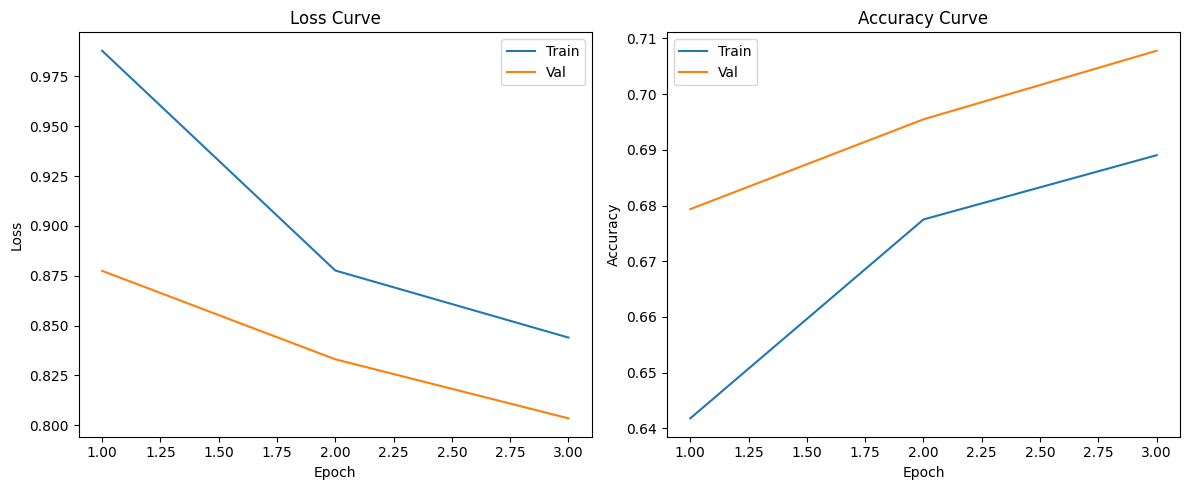

In [26]:
def plot_learning_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)


# Evaluation on test set

Test: 100%|██████████| 3708/3708 [26:19<00:00,  2.35it/s]



Classification report (test):
              precision    recall  f1-score   support

           0     0.7159    0.8792    0.7892     23507
           1     0.5953    0.2649    0.3667      3514
           2     0.6380    0.4177    0.5049     11297
           3     0.5000    0.0458    0.0838      1224
           4     0.7381    0.8423    0.7868     17472
           5     0.7189    0.4495    0.5531      2305

    accuracy                         0.7102     59319
   macro avg     0.6511    0.4832    0.5141     59319
weighted avg     0.6962    0.7102    0.6856     59319



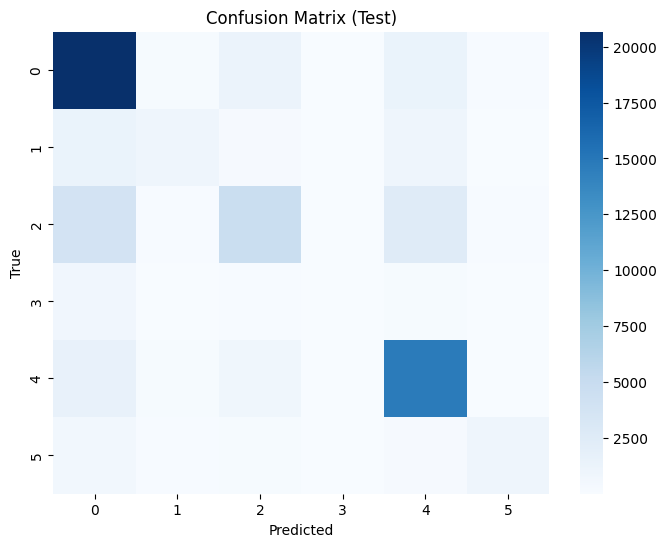

In [27]:
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("\nClassification report (test):")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
